In [8]:
%load_ext autoreload
%autoreload 2

import os
import json
import torch
import pandas as pd
import numpy as np
import optuna
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from scipy.ndimage import uniform_filter1d
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
from model_definition import LSTMClassifier, CNN1DClassifier, MLPClassifier                 # Load models

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Cleaned data processing

In [2]:
### DATA INGESTION
# V1

COL_NAMES_V1 = ["t_ms","ax","ay","az","gx","gy","gz","flex_raw","press_raw","vib_duty"]      # timestamp + 8 features + vibration motor output
WINDOW_SIZE = 25
STRIDE = 1

IN_CH = 30              # (8 + 2) * 3
NUM_CLASSES = 9

def process_raw_signal(df):
    df = df.astype(np.float32)
    sensors_only = df[:, 1:9]

    # Smooth
    cleaned_sensors = uniform_filter1d(sensors_only, size=3, axis=0)

    return cleaned_sensors

def engineer_features(df):
    # Extract and normalise to [-1, 1]
    SENSOR_RANGES = {
        'accel': 8.0 * 9.80665,            # +/-8 g
        'gyro': 500 * (np.pi / 180),       # +/-500 deg/s -> convert to rad/s
        'flex_min': 800,                   # some buffer for anyone
        'flex_max': 2100,    
        'press': 4095.0                    # 12b
    }

    df = df.astype(np.float32)

    accel = df[:, 0:3] / SENSOR_RANGES['accel']
    gyro = df[:, 3:6] / SENSOR_RANGES['gyro']
    flex = (df[:, 6:7] - SENSOR_RANGES['flex_min']) / (SENSOR_RANGES['flex_max'] - SENSOR_RANGES['flex_min'])
    flex = np.clip(flex, 0, 1)
    press = df[:, 7:8] / SENSOR_RANGES['press']
    
    # Get magnitudes
    accel_mag = np.linalg.norm(accel, axis=1, keepdims=True)
    gyro_mag = np.linalg.norm(gyro, axis=1, keepdims=True)

    features_base = np.hstack([accel, gyro, flex, press, accel_mag, gyro_mag])

    # Get mean and std dev for all
    w_mean = np.mean(features_base, axis=0)
    mean_feat = np.tile(w_mean, (features_base.shape[0], 1))
    w_std  = np.std(features_base, axis=0)
    std_feat  = np.tile(w_std, (features_base.shape[0], 1))

    return np.hstack([features_base, mean_feat, std_feat])

class GestureWindowDataset(Dataset):
    def __init__(self, csv_dir, labels_dict, window_size=WINDOW_SIZE, stride=STRIDE):
        self.samples = []
        
        for file_name, label in labels_dict.items():
            file_path = os.path.join(csv_dir, file_name)
            if not os.path.exists(file_path): 
                continue

            # Drop timestamp
            df = pd.read_csv(file_path, header=None, names=COL_NAMES_V1)
            raw_data = df.values
            processed_data = process_raw_signal(raw_data)
            
            T, F = processed_data.shape

            # Pad for smaller samples
            if T < window_size:
                padding = np.zeros((window_size - T, F))
                processed_data = np.vstack([processed_data, padding])
                T = window_size

            # Process windows
            for start in range(0, T - window_size + 1, stride):
                window_raw = processed_data[start:start + window_size].copy()
                
                window = engineer_features(window_raw)

                self.samples.append((
                    torch.tensor(window, dtype=torch.float32),
                    torch.tensor(label, dtype=torch.long)
                ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


### Data prep for cross-validation

In [3]:
### SPLIT DATA

def split_data(labels_dict, test_size=0.2):
    file_names = np.array(list(labels_dict.keys()))
    labels = np.array(list(labels_dict.values()))

    # 80-20
    cv_files, test_files, _, __ = train_test_split(
        file_names, labels, test_size=test_size, stratify=labels, random_state=42
    )

    cv_labels = {f: labels_dict[f] for f in cv_files}
    test_labels = {f: labels_dict[f] for f in test_files}
    return cv_labels, test_labels

data_folder_path = "data/v2/cleaned"
with open(os.path.join(data_folder_path, "labels.json"), "r") as f:
    labels_dict = json.load(f)

cv_labels, test_labels = split_data(labels_dict)

### Model training

In [23]:
### TRAINING HELPERS

def train_and_validate(model, train_loader, val_loader, criterion, optimiser, epochs, fold_idx=None, verbose=True):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    best_val_acc = 0.0
    best_val_f1 = 0.0

    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()
        total_loss = 0
        
        for batch_features, batch_labels in train_loader:
            # CNN expects (B, C, L); LSTM/MLP use (B, L, C).
            if isinstance(model, CNN1DClassifier):
                batch_features = batch_features.transpose(1, 2)
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device).long()
            
            optimiser.zero_grad()
            outputs = model(batch_features)
            loss = criterion(outputs, batch_labels)

            if torch.isnan(loss):
                print(f"NaN detected at Fold {fold_idx}, Epoch {epoch+1}")
                return 0.0, 0.0
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Added for stability
            optimiser.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        
        # --- Validation Phase ---
        model.eval()
        correct, total = 0, 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for batch_features, batch_labels in val_loader:
                if isinstance(model, CNN1DClassifier):
                    batch_features = batch_features.transpose(1, 2)
                batch_features = batch_features.to(device)
                batch_labels = batch_labels.to(device)
                
                outputs = model(batch_features)
                _, predicted = torch.max(outputs.data, 1)

                total += batch_labels.size(0)
                correct += (predicted == batch_labels).sum().item()
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(batch_labels.cpu().numpy())
        
        val_acc = 100 * correct / total
        best_val_acc = max(best_val_acc, val_acc)
        val_f1 = f1_score(all_labels, all_preds, average='macro')
        best_val_f1 = max(best_val_f1, val_f1)

        # Print progress
        if verbose:
            fold_str = f"Fold {fold_idx} | " if fold_idx is not None else ""
            print(f"{fold_str}Epoch [{epoch+1}/{epochs}] | Loss: {avg_train_loss:.4f} | Acc: {val_acc:.2f}% | F1: {val_f1:.4f}")
    
    return best_val_acc, best_val_f1

In [24]:
### HYPERPARAMETER TUNING

def objective(trial, cv_labels, data_path, folds=3, use_augment=True):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Suggest hyperparameters
    lr = trial.suggest_float("lr", 2e-4, 1.2e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32])
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 8e-5, log=True)
    
    files = np.array(list(cv_labels.keys()))
    labels = np.array(list(cv_labels.values()))
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)    # 3-fold is faster for tuning
    
    fold_accuracies = []
    fold_f1 = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(files, labels)):
        # Setup data
        train_labels = {f: cv_labels[f] for f in files[train_idx]}
        val_labels = {f: cv_labels[f] for f in files[val_idx]}
        
        train_ds = GestureWindowDataset(data_path, train_labels, stride=1)
        val_ds = GestureWindowDataset(data_path, val_labels, stride=5)
        
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

        # Setup model
        model = LSTMClassifier(input_size=IN_CH, num_classes=NUM_CLASSES, hidden_size=64, num_layers=2)
        optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.05)

        # Train fold
        best_acc, best_f1 = train_and_validate(
            model, train_loader, val_loader, criterion, optimiser, 
            epochs=10, fold_idx=fold+1
        )

        fold_accuracies.append(best_acc)
        fold_f1.append(best_f1)
        
        # Prune
        # trial.report(np.mean(fold_accuracies), fold)
        trial.report(np.mean(fold_f1), fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(fold_f1)  # Optimise for F1

sampler = optuna.samplers.TPESampler(seed=42, multivariate=True)
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)
study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study = optuna.create_study(direction="maximize")
study.optimize(lambda trial: objective(trial, cv_labels, data_folder_path, use_augment=True), n_trials=1)
best_params = study.best_trial.params

print("\n" + "=" * 70)
print("--- Optimization Finished ---")
print(f"Best F1 Score: {study.best_value:.4f}")
print(f"Best params:")
for key, val in best_params.items():
    print(f"  {key}: {val}")
print("=" * 70)

c:\Users\Willson\anaconda3\envs\ml\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-04-11 16:20:08,637] A new study created in memory with name: no-name-d173d02b-381b-49d3-831e-5ee15235137b
[I 2026-04-11 16:20:08,637] A new study created in memory with name: no-name-fd1c2872-4cec-4fd5-a456-e78a2a4ff08d


Fold 1 | Epoch [1/10] | Loss: 1.2345 | Acc: 58.89% | F1: 0.5635
Fold 1 | Epoch [2/10] | Loss: 0.8246 | Acc: 63.39% | F1: 0.6510
Fold 1 | Epoch [3/10] | Loss: 0.7094 | Acc: 69.95% | F1: 0.7209
Fold 1 | Epoch [4/10] | Loss: 0.6574 | Acc: 70.53% | F1: 0.7143
Fold 1 | Epoch [5/10] | Loss: 0.6129 | Acc: 73.85% | F1: 0.7569
Fold 1 | Epoch [6/10] | Loss: 0.5864 | Acc: 73.55% | F1: 0.7463
Fold 1 | Epoch [7/10] | Loss: 0.5615 | Acc: 69.39% | F1: 0.7029
Fold 1 | Epoch [8/10] | Loss: 0.5476 | Acc: 72.96% | F1: 0.7434
Fold 1 | Epoch [9/10] | Loss: 0.5286 | Acc: 68.15% | F1: 0.6885
Fold 1 | Epoch [10/10] | Loss: 0.5124 | Acc: 73.55% | F1: 0.7429
Fold 2 | Epoch [1/10] | Loss: 1.2253 | Acc: 67.29% | F1: 0.6833
Fold 2 | Epoch [2/10] | Loss: 0.8477 | Acc: 72.75% | F1: 0.7340
Fold 2 | Epoch [3/10] | Loss: 0.7363 | Acc: 76.68% | F1: 0.7758
Fold 2 | Epoch [4/10] | Loss: 0.6689 | Acc: 73.63% | F1: 0.7428
Fold 2 | Epoch [5/10] | Loss: 0.6274 | Acc: 75.93% | F1: 0.7670
Fold 2 | Epoch [6/10] | Loss: 0.5958 | 

[I 2026-04-11 16:26:05,346] Trial 0 finished with value: 0.7502516682919277 and parameters: {'lr': 0.0005734451917021063, 'batch_size': 32, 'weight_decay': 1.910300426533359e-05}. Best is trial 0 with value: 0.7502516682919277.


Fold 3 | Epoch [10/10] | Loss: 0.4777 | Acc: 69.63% | F1: 0.7109

--- Optimization Finished ---
Best F1 Score: 0.7503
Best params:
  lr: 0.0005734451917021063
  batch_size: 32
  weight_decay: 1.910300426533359e-05


In [25]:
### FINAL MODEL TRAINING

def train_final_model(cv_labels, test_labels, best_params, data_path, epochs=40):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    train_ds = GestureWindowDataset(data_path, cv_labels, stride=1)
    test_ds = GestureWindowDataset(data_path, test_labels, stride=5)
    
    batch_size = best_params['batch_size']
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    
    model = LSTMClassifier(input_size=IN_CH, num_classes=NUM_CLASSES, hidden_size=64, num_layers=2)
    weight_decay = best_params.get('weight_decay', 1e-4)
    optimizer = torch.optim.Adam(model.parameters(), lr=best_params['lr'], weight_decay=weight_decay)
    criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.05)

    
    print("\n" + "=" * 70)
    print("Training Final Model on Full CV Pool")
    print("=" * 70)
    final_acc, final_f1 = train_and_validate(
        model, train_loader, test_loader, criterion, optimizer, 
        epochs=epochs, fold_idx="FINAL"
    )
    
    print(f"\nFinal Model Test Accuracy: {final_acc:.2f}% | Test F1: {final_f1:.4f}")
    return model

epochs = 2
final_model = train_final_model(cv_labels, test_labels, best_params, data_folder_path, epochs)


Training Final Model on Full CV Pool
Fold FINAL | Epoch [1/2] | Loss: 1.1498 | Acc: 66.71% | F1: 0.6680
Fold FINAL | Epoch [2/2] | Loss: 0.7538 | Acc: 69.65% | F1: 0.7091

Final Model Test Accuracy: 69.65% | Test F1: 0.7091


### Evaluation


Overall Test Accuracy: 69.65%
------------------------------
              precision    recall  f1-score   support

        chop     0.7829    0.6171    0.6902       444
      select     0.4432    0.7667    0.5617       570
       shake     0.9679    0.9801    0.9739       553
     squeeze     0.6215    0.9741    0.7588       617
        stir     0.7758    0.8270    0.8006       682
     swipe_l     0.6260    0.4067    0.4931       922
     swipe_r     0.6419    0.3591    0.4605       674
     twist_l     0.8594    0.8653    0.8623       438
     twist_r     0.8928    0.6937    0.7808       480

    accuracy                         0.6965      5380
   macro avg     0.7346    0.7211    0.7091      5380
weighted avg     0.7180    0.6965    0.6872      5380

Macro avg    | Precision: 0.734594 | Recall: 0.721085 | F1: 0.709106
Weighted avg | Precision: 0.717994 | Recall: 0.696468 | F1: 0.687154


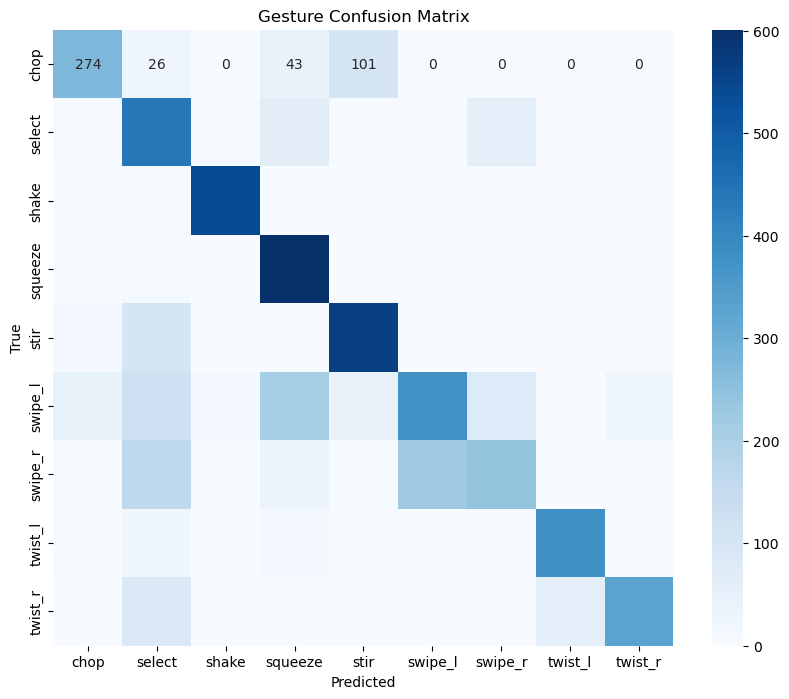

In [26]:
def evaluate_final_model(model, test_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch_features, batch_labels in test_loader:
            if isinstance(model, CNN1DClassifier):
                batch_features = batch_features.transpose(1, 2)
            batch_features = batch_features.to(device)
            
            outputs = model(batch_features)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_labels.numpy())
    
    # Print metrics
    accuracy = accuracy_score(all_labels, all_preds)
    print(f"\nOverall Test Accuracy: {accuracy * 100:.2f}%")
    print("-" * 30)

    with open("v2/gesture_map.json", "r") as file:
        gesture_map = json.load(file)

    # print(classification_report(all_labels, all_preds, target_names=gesture_map.keys()))
    report_text = classification_report(
        all_labels, all_preds, target_names=gesture_map.keys(), digits=4, zero_division=0
    )
    report_dict = classification_report(
        all_labels, all_preds, target_names=gesture_map.keys(), output_dict=True, zero_division=0
    )

    print(report_text)
    print(f"Macro avg    | Precision: {report_dict['macro avg']['precision']:.6f} | Recall: {report_dict['macro avg']['recall']:.6f} | F1: {report_dict['macro avg']['f1-score']:.6f}")
    print(f"Weighted avg | Precision: {report_dict['weighted avg']['precision']:.6f} | Recall: {report_dict['weighted avg']['recall']:.6f} | F1: {report_dict['weighted avg']['f1-score']:.6f}")
    
    # Generate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=gesture_map.keys(), yticklabels=gesture_map.keys())
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Gesture Confusion Matrix')
    plt.show()

    return all_preds, all_labels
    
batch_size = study.best_params['batch_size']
test_ds = GestureWindowDataset(data_folder_path, test_labels, stride=5)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
all_preds, all_labels = evaluate_final_model(final_model, test_loader)

### Export model

In [27]:
### EXPORT MODEL WEIGHTS FOR HLS

from weights_to_cpp import export_hls_weights

HLS_OUTPUT_DIR = os.path.normpath(os.path.join("..", "model_to_hls", "cg4002_cnn"))
exported_header = export_hls_weights(final_model, HLS_OUTPUT_DIR)
print(f"Exported HLS weights to: {exported_header}")

LSTM weights saved to ..\model_to_hls\cg4002_cnn\lstm_weights.h
Exported HLS weights to: ..\model_to_hls\cg4002_cnn\lstm_weights.h


In [30]:
### EXPORT TEST SET

target_dir = f"../to_ultra96/v{VERSION}/test_set"
os.makedirs(target_dir, exist_ok=True)

all_test_features = []
all_test_labels = []

for features, label in test_ds:
    # Transpose to match HLS (IN_CH,IN_LEN)
    all_test_features.append(features.numpy().T)
    all_test_labels.append(label)

np.save(os.path.join(target_dir, "x_test.npy"), np.array(all_test_features).astype(np.float32))
np.save(os.path.join(target_dir, "y_test.npy"), np.array(all_test_labels))

### Validation against Vitis HLS

In [31]:
### LOAD MODEL

loaded_model = CNN1DClassifier(input_size=IN_CH, num_classes=NUM_CLASSES)
loaded_model.load_state_dict(
    torch.load(f"v{VERSION}/cnn_weights.pth", map_location=torch.device('cpu'))
)
loaded_model.eval()

CNN1DClassifier(
  (conv_block): Sequential(
    (0): Conv1d(30, 32, kernel_size=(7,), stride=(1,))
    (1): LeakyReLU(negative_slope=0.1)
    (2): Dropout(p=0.2, inplace=False)
    (3): Conv1d(32, 64, kernel_size=(3,), stride=(1,))
    (4): LeakyReLU(negative_slope=0.1)
    (5): AdaptiveAvgPool1d(output_size=1)
  )
  (fc): Linear(in_features=64, out_features=9, bias=True)
)

In [32]:
### PREPARE DATA FOR VITIS HLS TESTBENCH
# WINDOW_SIZE changes this

def export_test_sample(csv_file_path, ver=VERSION):
    df = pd.read_csv(csv_file_path, header=None, names=COL_NAMES_V2)
    raw_data = df.values
    processed_data = process_raw_signal(raw_data)
    
    T, F = processed_data.shape
    if T < WINDOW_SIZE:
        padding = np.zeros((WINDOW_SIZE - T, F))
        processed_data = np.vstack([processed_data, padding])
    
    window_raw = processed_data[0:WINDOW_SIZE].copy()
    window_feat = engineer_features_v2(window_raw)
    
    # Convert to Channels-First for Vitis HLS
    hls_ready = window_feat.T               # (IN_CH, IN_LEN)
    flattened = hls_ready.flatten()
    
    filename = csv_file_path.split("/")[-1]
    output_path = f"data/v{ver}/vitis_hls_sample/sample_{filename}"
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    with open(output_path, "w") as f:
        for val in flattened:
            f.write(f"{val:.8f}\n")
            
    return torch.tensor(hls_ready).unsqueeze(0) # For checking in Python

files_to_export = [
    "chop_1.txt",
    # "knead_1.txt",
    "select_1.txt",
    "shake_1.txt",
    "squeeze_1.txt",
    "stir_1.txt",
    "swipe_l_1.txt",
    "swipe_r_1.txt",
    "twist_l_1.txt",
    "twist_r_1.txt"
]

for file in files_to_export:
    sample_tensor = export_test_sample(f"data/v2/cleaned/{file}")
    with torch.no_grad():
        py_output = loaded_model(sample_tensor)
        clean_output = ",".join(f"{x:.3f}" for x in py_output.flatten().tolist())
        print(f"{{{clean_output}}},")

{-0.179,-6.369,-2.402,-4.325,-3.797,-4.423,-3.974,-5.640,-3.856},
{-2.920,4.150,-1.604,-0.014,-4.435,-3.228,-1.253,-3.870,-3.212},
{-6.054,-4.288,1.511,-3.832,1.860,-2.661,-3.130,-3.177,-3.354},
{-1.908,-0.581,-2.808,1.454,-2.979,-4.931,-2.893,-3.567,-4.763},
{-1.736,-1.969,-3.741,-0.974,0.581,-3.571,-3.792,-3.753,-5.147},
{-3.007,1.257,-2.573,-2.552,-0.197,2.422,-2.777,-3.425,-1.226},
{-2.772,2.078,-2.865,0.576,-2.686,3.153,-1.348,-2.305,-1.100},
{0.933,0.586,-0.276,0.500,1.781,-0.397,1.760,6.302,-0.786},
{-1.067,-1.848,-3.185,0.040,-2.671,-2.651,-4.812,-3.908,-3.424},
